In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
#from sklearn.decomposition import PCA
#from sklearn.neighbors import NearestNeighbors
#import igraph as ig
#import leidenalg as la
#from umap.umap_ import fuzzy_simplicial_set
#import umap
import os
import math
#import pickle
from natsort import natsorted
from pathlib import Path

import anndata as ad
import warnings
warnings.filterwarnings('ignore')
#import tensorflow as tf


import sys
import pickle


In [2]:
home_dir = Path.home()

src_dir = home_dir / 'ext_hd_sammy' / 'projects' / 'out' / 'out_msi' 
dst_folder = home_dir / 'ext_hd_sammy' / 'projects' / 'out' / 'out_msi' / 'script05_output'
os.makedirs(dst_folder, exist_ok=True)

In [15]:
peptides = src_dir / 'peptide_msi'
glycans = src_dir / 'glycan_msi'
metab = src_dir / 'metab_msi'

os.listdir(glycans)

['glycan_S033',
 'glycan_S032',
 'glycan_S045',
 'glycan_S044',
 'glycan_S034',
 'glycan_S024']

In [18]:
import os
import pandas as pd
import tqdm

# Define data path
data = os.listdir(glycans) # List of file names
data_path = glycans / data[2]

# Initialize the first dataframe
obs = None

files = os.listdir(data_path)
# Iterate through all glycan files
for i in tqdm.tqdm(range(len(files))):
    file_path = os.path.join(data_path, files[i])

    # Read file with optimized dtypes
    df_temp = pd.read_parquet(file_path)

    # Extract proper channel name from the filename
    channel_name = '_'.join(files[i].split('.')[0].split('_')[1:4])  

    # Select only necessary columns and rename intensity column
    df_temp = df_temp[['x', 'y', 'intensity']].copy()
    df_temp.rename(columns={'intensity': channel_name}, inplace=True)

    # Convert to smaller dtype to reduce memory
    df_temp[channel_name] = df_temp[channel_name].astype('float32')

    # Merge iteratively to reduce memory overhead
    if obs is None:
        obs = df_temp
    else:
        obs = obs.merge(df_temp, on=['x', 'y'], how='outer')

    # Free up memory after processing each file
    del df_temp
    
# Show first few rows
print(obs.head())

100%|██████████| 160/160 [00:06<00:00, 24.21it/s]

    x    y  glycans_channel_109  glycans_channel_105  glycans_channel_81  \
0  50  384              10508.0              11119.0                 NaN   
1  50  385              37811.0              23491.0              1529.0   
2  50  386               6586.0              34947.0              4257.0   
3  50  387                  NaN              11164.0                 NaN   
4  50  388              19310.0              14429.0                 NaN   

   glycans_channel_49  glycans_channel_46  glycans_channel_15  \
0             10865.0             42163.0                 NaN   
1             16057.0             39534.0                 NaN   
2             21584.0                 NaN                 NaN   
3             10988.0              6409.0                 NaN   
4                 NaN                 NaN                 NaN   

   glycans_channel_102  glycans_channel_128  ...  glycans_channel_131  \
0              28271.0              22214.0  ...               8360.0   
1     

<Axes: xlabel='x', ylabel='y'>

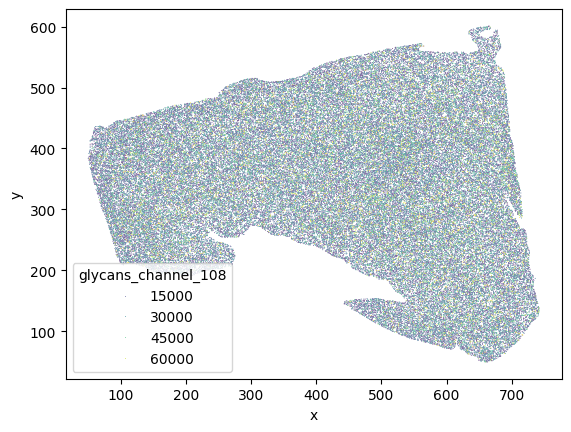

In [26]:
channel = 'glycans_channel_108'

obs = obs.sort_values(by=channel, ascending=True)
sns.scatterplot(data=obs, x='x', y='y', hue=channel, palette='viridis', s=.45)

In [27]:
obs.fillna(0, inplace=True)  # Fill NaN values with 0

In [ ]:
### perform normalization using z-score
from sklearn.preprocessing import StandardScaler

coordinates = obs[['x', 'y']].values
intensities = obs.drop(columns=['x', 'y']).values

scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)

# Create a new DataFrame with scaled intensities
scaled_obs = pd.DataFrame(intensities_scaled, columns=obs.columns[2:], index=obs.index)
scaled_obs[['x', 'y']] = obs[['x', 'y']].values

### perform PCA on the scaled intensities and UMAP for visualization
from sklearn.decomposition import PCA
from umap import UMAP   
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_obs.drop(columns=['x', 'y']).values)


ValueError: Could not interpret value `glycans_channel_108` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x800 with 0 Axes>

In [35]:

umap_model = UMAP(n_neighbors=50, min_dist=0.1, metric='euclidean')
umap_result = umap_model.fit_transform(pca_result)  

# Create a DataFrame for UMAP results
umap_df = pd.DataFrame(umap_result, columns=['UMAP1', 'UMAP2'])
umap_df[['x', 'y']] = scaled_obs[['x', 'y']].values


#plt.savefig(dst_folder / 'umap_projection.png', dpi=300)

In [30]:
final_df = pd.concat([umap_df, obs.drop(columns=['x', 'y'])], axis=1)

In [31]:
final_df

,UMAP1,UMAP2,x,y,glycans_channel_109,glycans_channel_105,glycans_channel_81,glycans_channel_49,glycans_channel_46,glycans_channel_15,...,glycans_channel_131,glycans_channel_149,glycans_channel_80,glycans_channel_151,glycans_channel_73,glycans_channel_123,glycans_channel_52,glycans_channel_47,glycans_channel_118,glycans_channel_136
0,0.194522,-9.161671,53,376,10508.0,11119.0,0.0,10865.0,42163.0,0.0,...,8360.0,13582.0,0.0,0.0,32635.0,0.0,44957.0,12951.0,6914.0,0.0
1,1.613787,-4.997528,444,219,37811.0,23491.0,1529.0,16057.0,39534.0,0.0,...,5802.0,23955.0,28906.0,10042.0,52397.0,0.0,0.0,30330.0,50814.0,12092.0
2,-4.669474,-6.140657,57,366,6586.0,34947.0,4257.0,21584.0,0.0,0.0,...,16041.0,0.0,17669.0,11766.0,0.0,36803.0,65535.0,35596.0,9118.0,5246.0
3,-4.746075,-6.134944,506,200,0.0,11164.0,0.0,10988.0,6409.0,0.0,...,8059.0,0.0,32250.0,47838.0,42999.0,0.0,18329.0,0.0,6403.0,0.0
4,17.728874,12.418461,91,311,19310.0,14429.0,0.0,0.0,0.0,0.0,...,0.0,0.0,9153.0,0.0,0.0,0.0,0.0,0.0,0.0,33564.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225121,7.239062,-8.528547,739,151,15809.0,0.0,6812.0,0.0,0.0,15438.0,...,33692.0,9481.0,21699.0,3138.0,14557.0,0.0,29760.0,0.0,13605.0,0.0
225122,6.911190,-9.458379,740,137,0.0,0.0,0.0,28412.0,0.0,0.0,...,0.0,15051.0,0.0,0.0,65535.0,0.0,0.0,0.0,0.0,0.0
225123,0.599071,-9.362857,740,140,0.0,1469.0,0.0,14812.0,0.0,13298.0,...,20130.0,35989.0,65535.0,4562.0,40584.0,0.0,17042.0,0.0,7165.0,0.0
225124,1.464200,-8.658245,740,145,19463.0,3296.0,0.0,0.0,22578.0,0.0,...,0.0,0.0,42462.0,0.0,43315.0,21360.0,0.0,0.0,0.0,0.0


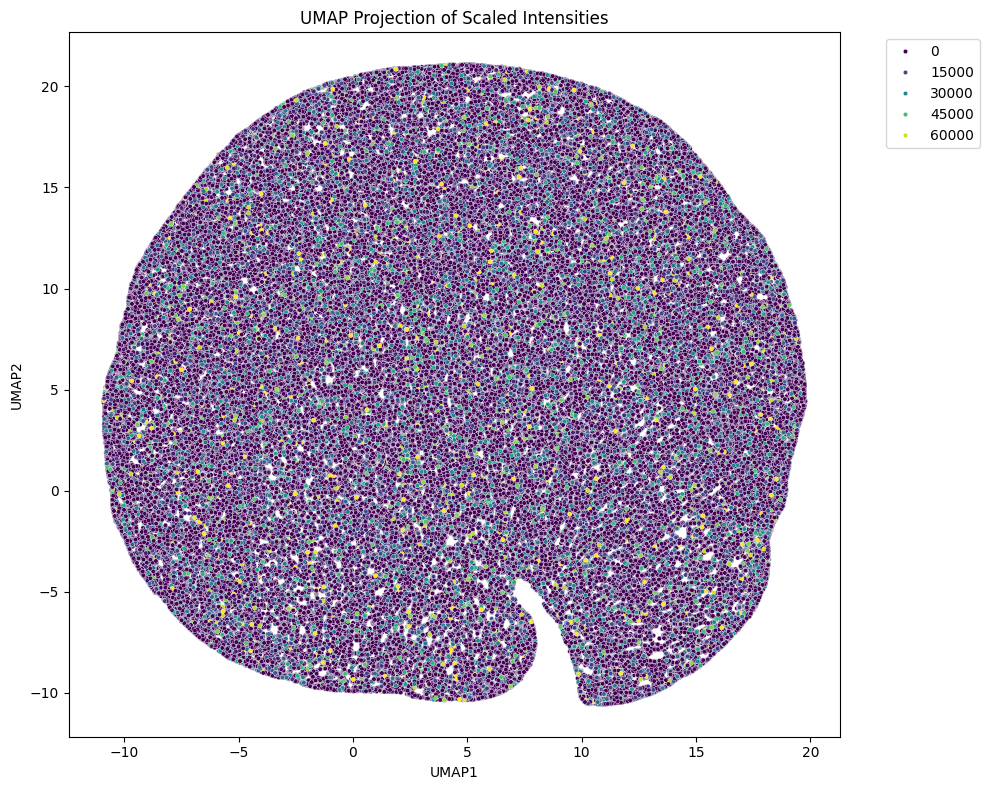

In [34]:
# Plot UMAP results
plt.figure(figsize=(10, 8))
sns.scatterplot(data=final_df, x='UMAP1', y='UMAP2', hue=channel, palette='viridis', s=10)
plt.title('UMAP Projection of Scaled Intensities')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()